# LendMind

### 1) Importing Libraries

##### -----> General Stuff

In [99]:
#!pip install numpy==2.2.0
#!pip install pandas==2.2.3
#!pip install scikit-learn==1.6.0
#!pip install matplotlib==3.9.3

In [100]:
import joblib
import numpy as np 
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

##### -----> For Random Forest model

In [101]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score , classification_report, roc_auc_score, roc_curve

##### -----> For Multiple Linear Regression model

In [102]:
from sklearn import linear_model

### 2) Read The Data

In [103]:
df = pd.read_csv(r'../data/cleaned_data.csv')
print(df.shape)
df.sample(1)

(100000, 16)


,int_rate,dti,installment,annual_inc,revol_util,avg_cur_bal,revol_bal,bc_open_to_buy,tot_cur_bal,mo_sin_old_rev_tl_op,loan_amnt,bc_util,total_bc_limit,total_bal_ex_mort,total_rev_hi_lim,loan_status
56446,19.99,18.5,662.21,70000.0,78.0,16302.0,24497,5703.0,211922.0,153.0,25000,81.1,30200.0,28214.0,31400.0,0


 ### 3) buildind models

--> (a) RandomForest

In [104]:
x_rf = df.drop(columns='loan_status', axis=1)
y_rf = df['loan_status']
x_train_rf, x_test_rf, y_train_rf, y_test_rf = train_test_split(x_rf, y_rf, test_size=0.2, random_state=42)

In [105]:
scaler_rf = StandardScaler()
x_train_rf_scaled = scaler_rf.fit_transform(x_train_rf)
x_test_rf_scaled = scaler_rf.transform(x_test_rf)

In [106]:
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(x_train_rf_scaled, y_train_rf)

RandomForestClassifier(max_depth=10, random_state=42)

In [107]:
joblib.dump(rf_model, '../server/saved_models/rf_model.pkl')
print("✅The model was successfully saved in: ../server/saved_models/rf_model.pkl")


joblib.dump(scaler_rf, '../server/saved_models/scaler_rf.pkl')
print("✅The Scaler was successfully saved in: ../server/saved_models/scaler_rf.pkl")

✅The model was successfully saved in: ../server/saved_models/rf_model.pkl
✅The Scaler was successfully saved in: ../server/saved_models/scaler_rf.pkl


--> (b) Multiple Linear Regression


In [108]:
correct_df = df[df['loan_status'] == 0].drop(columns='loan_status')
x_mlr = correct_df.drop(columns='loan_amnt')
y_mlr = correct_df['loan_amnt']
x_train_mlr, x_test_mlr, y_train_mlr, y_test_mlr = train_test_split(x_mlr, y_mlr, test_size=0.2, random_state=42)

scaler_mlr = StandardScaler()

x_train_mlr_scaled = scaler_mlr.fit_transform(x_train_mlr)
x_test_mlr_scaled = scaler_mlr.transform(x_test_mlr)

In [109]:
mlr_model = linear_model.LinearRegression()

mlr_model.fit(x_train_mlr_scaled, y_train_mlr)

coef_ =  mlr_model.coef_
intercept_ = mlr_model.intercept_

print (f'Coefficients: {coef_}')
print (f'Intercept: {intercept_}')

Coefficients: [ 106.73065132  -34.95532157 8010.0174393    29.63938519  -43.37271818
  174.35467823  -99.36716024  -82.77468129  114.71644183  -14.96898913
 -156.82920749  458.8155753    45.53062093   82.70384306]
Intercept: 14062.879375


In [110]:
joblib.dump(mlr_model, '../server/saved_models/mlr_model.pkl')
print("✅The model was successfully saved in: ../server/saved_models/mlr_model.pkl")

joblib.dump(scaler_mlr, '../server/saved_models/scaler_mlr.pkl')
print("✅The Scaler was successfully saved in: ../server/saved_models/scaler_mlr.pkl")

✅The model was successfully saved in: ../server/saved_models/mlr_model.pkl
✅The Scaler was successfully saved in: ../server/saved_models/scaler_mlr.pkl


 ### 4) Evalute models

--> (a) RandomForest

ROC-AUC Score: 0.70


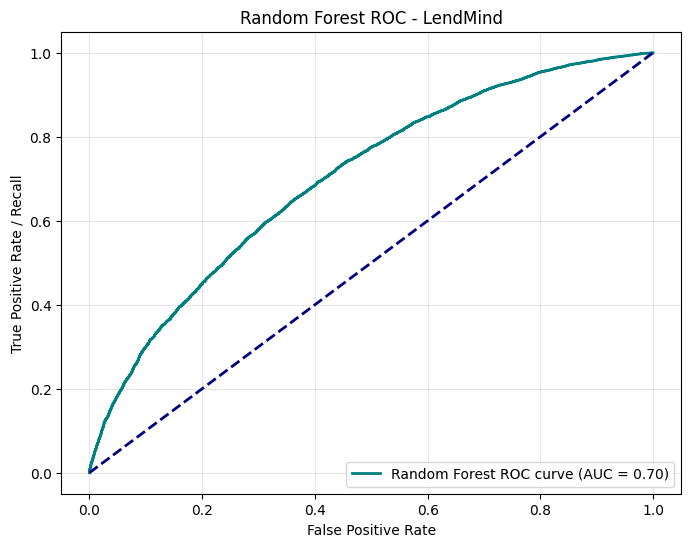

In [111]:
y_prob_rf = rf_model.predict_proba(x_test_rf_scaled)[:, 1]

auc_score_rf = roc_auc_score(y_test_rf, y_prob_rf)
print(f"ROC-AUC Score: {auc_score_rf:.2f}")


fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test_rf, y_prob_rf)
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='teal', lw=2, label=f'Random Forest ROC curve (AUC = {auc_score_rf:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate / Recall')
plt.title('Random Forest ROC - LendMind')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [112]:
y_pred_rf = rf_model.predict(x_test_rf_scaled)
accuracy = accuracy_score(y_test_rf, y_pred_rf)
print(f'accuracy: {accuracy:.2f}')
print(classification_report(y_test_rf, y_pred_rf))

accuracy: 0.64
              precision    recall  f1-score   support

           0       0.65      0.62      0.63      9922
           1       0.64      0.67      0.65     10078

    accuracy                           0.64     20000
   macro avg       0.64      0.64      0.64     20000
weighted avg       0.64      0.64      0.64     20000



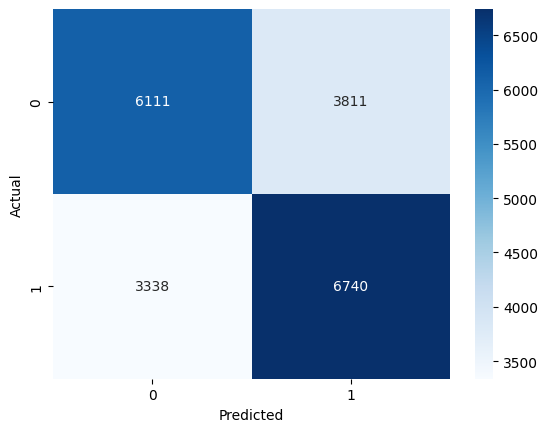

In [113]:
cm = confusion_matrix(y_test_rf, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

--> (b) Multiple Linear Regression
